<a href="https://colab.research.google.com/github/swetha25336/Diabetes-Prediction/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 0
Import Required Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings

# Ignore warnings for a cleaner output
warnings.filterwarnings("ignore")

# Set the visual style for plots
sns.set_style("whitegrid")

# Loading the dataset (assuming the file is named 'diabetes.csv')
diabetes_dataset = pd.read_csv('diabetes.csv')

TASK 1
LOAD THE DATASET

In [50]:
# loading the diabetes dataset to a pandas DataFrame
df= pd.read_csv('/content/diabetes.csv')


TASK 2 EXPLORATORY DATA ANALYSIS

DISPLAY FIRST 5 ROWS OF DATASET


In [51]:
# Display first 5 rows
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


DISPLAY LAST 5 ROWS OF DATASET

In [52]:
diabetes_dataset.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


CHECK THE SHAPE OF THE DATASET

In [53]:
diabetes_dataset.shape

(768, 9)

DISPLAY DATASET INFORMATION

In [54]:
# Dataset Information
diabetes_dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


DISPLAY STATISTICAL SUMMARY OF DATASET

In [55]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


CHECK FOR MISSING VALUES

In [56]:
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


CHECK ZERO VALUES IN SELECTED COLUMNS

In [57]:
columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in columns:
    print(col, (diabetes_dataset[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


TASK 3 TARGET VARIABLE ANALYSIS
📌 TOPIC: OUTCOME DISTRIBUTION

DISPLAY UNIQUE VALUES OF TARGET COLUMN

In [58]:
diabetes_dataset['Outcome'].unique()

array([1, 0])

COUNT VALUES OF TARGET COLUMN

In [59]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


CALCULATE PERCENTAGE DISTRIBUTION OF TARGET VARIABLE

In [60]:
outcome_counts = diabetes_dataset['Outcome'].value_counts()

percentage = (outcome_counts / len(diabetes_dataset)) * 100

print("Percentage Distribution:\n")
print(percentage)

Percentage Distribution:

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


VISUALIZING OUTCOME DISTRIBUTION

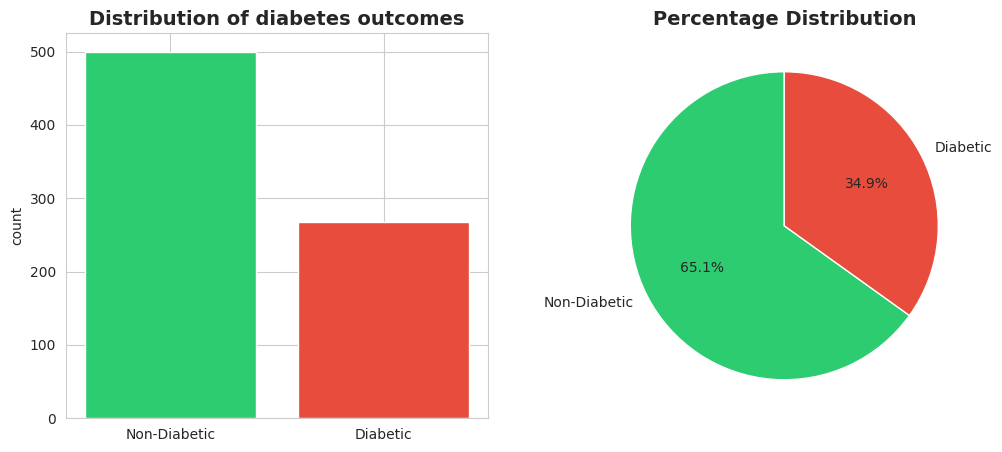

In [61]:
# Set the figure size for the side-by-side plots
plt.figure(figsize=(12, 5))

# Subplot 1: Bar Chart showing the count of each outcome
plt.subplot(1, 2, 1)
outcome_counts = diabetes_dataset['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

# Subplot 2: Pie Chart showing the percentage distribution
plt.subplot(1, 2, 2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')

# Display the figure
plt.show()


TASK 4 GROUP DATA BY OUTCOME AND CALCULATE MEAN

In [62]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


TASK 5: CORRELATION ANALYSIS


TOPIC: RELATIONSHIP BETWEEN FEATURES

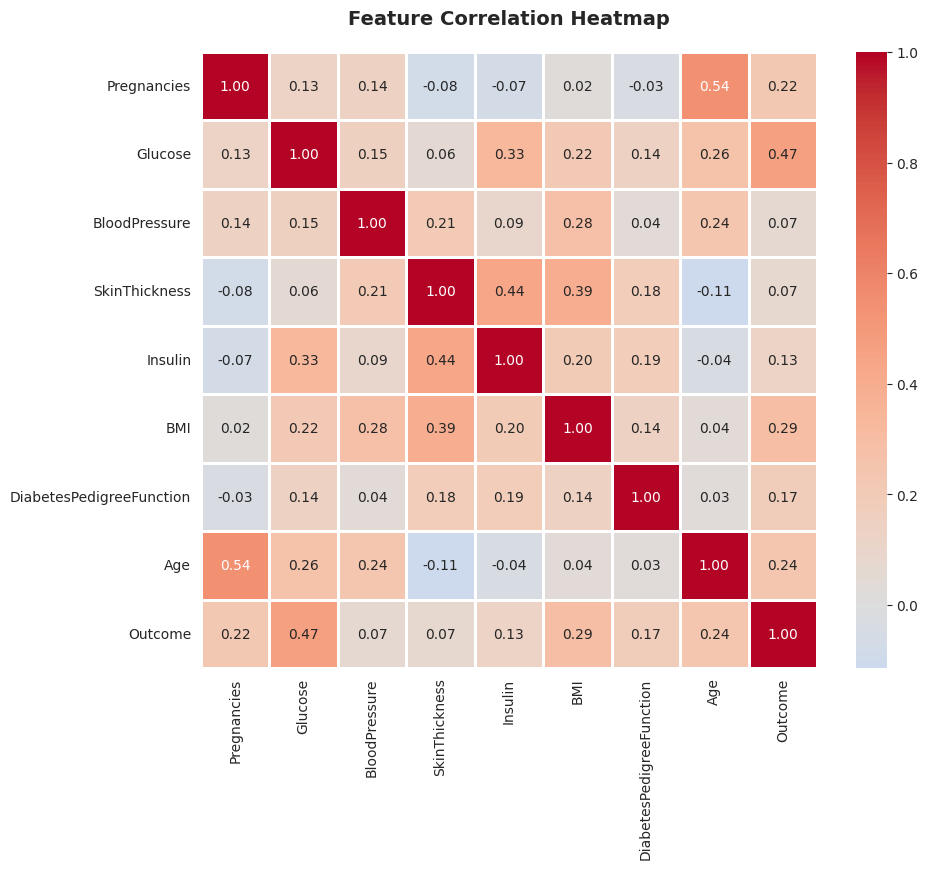

In [63]:
# Defining the figure size
plt.figure(figsize=(10, 8))

# Calculating the correlation matrix
correlation = diabetes_dataset.corr()

# Plotting the heatmap using Seaborn
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidth=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, pad=20, fontweight='bold')

plt.show()


TASK 6 FEATURE DISTRIBUTION ANALYSIS

PLOT HISTOGRAM FOR DATASET

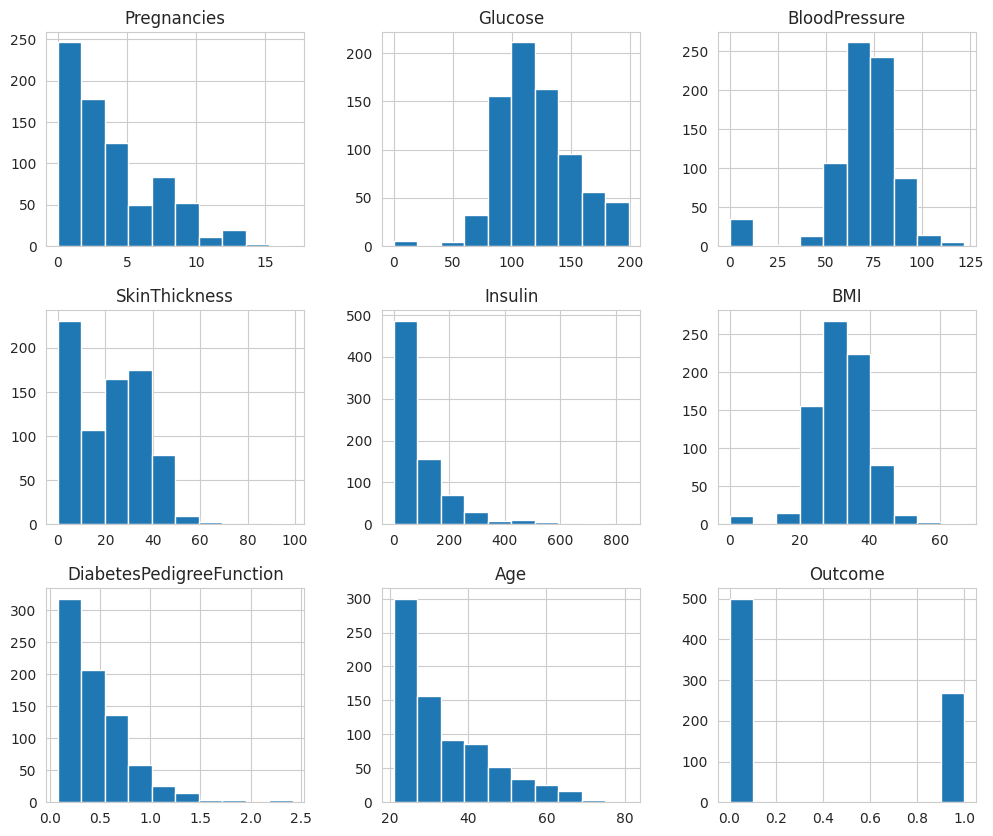

In [64]:
# Histogram
diabetes_dataset.hist(figsize=(12,10))
plt.show()

PLOT BOXPLOT FOR OUTLIER DETECTION

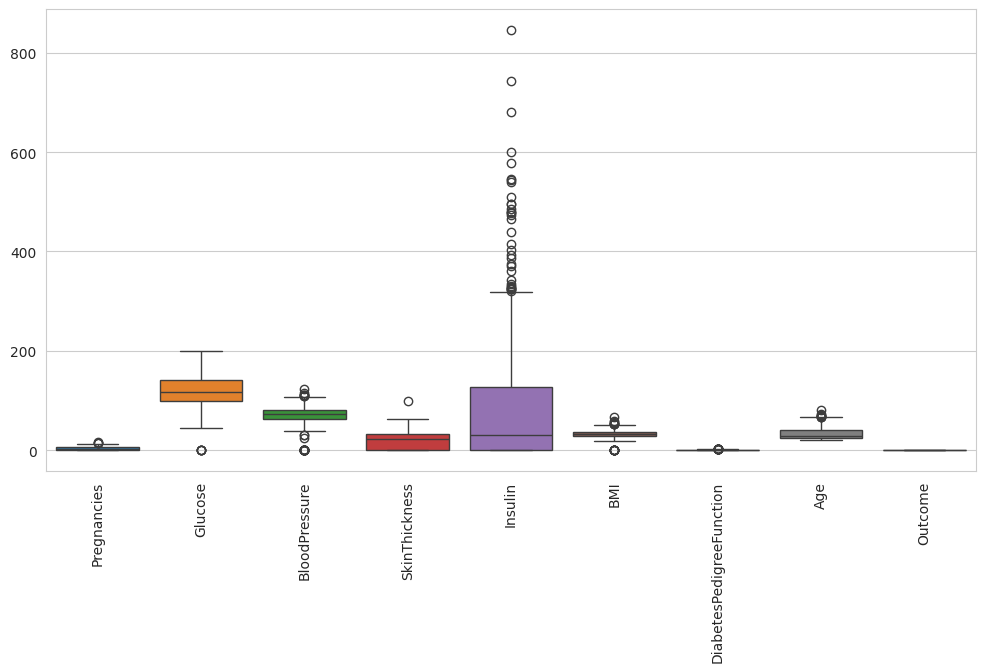

In [65]:
# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=diabetes_dataset)
plt.xticks(rotation=90)
plt.show()

FEATURE DISTRIBUTION BY OUTCOME

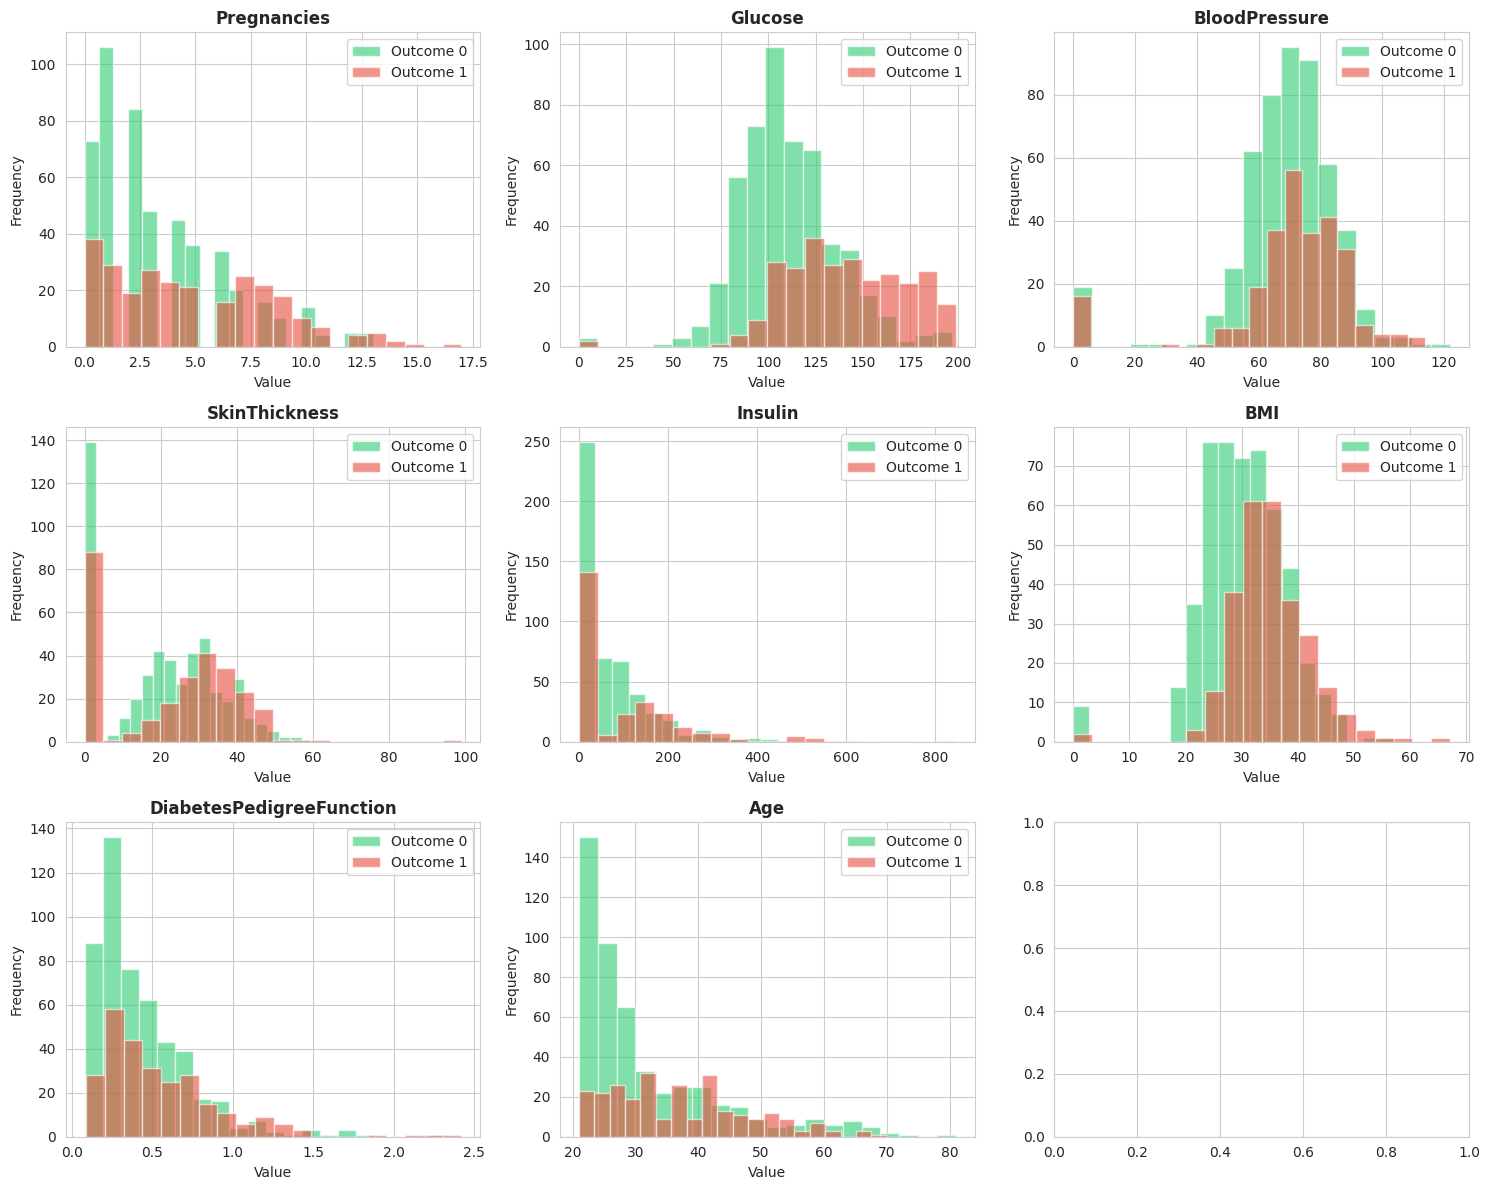

In [66]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    for outcome in [0, 1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature]
        axes[row, col].hist(data, alpha=0.6, bins=20, label=f'Outcome {outcome}',
                            color=['#2ecc71', '#e74c3c'][outcome])

    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout() # Added for better spacing between plots
plt.show()


SEPARATING FEATURES (X) AND TARGET (Y)

TOPIC: DATA PREPARATION

In [67]:
# Dropping the target column to create the feature set (X)
X = diabetes_dataset.drop(columns='Outcome', axis=1)

# Storing the target column separately (Y)
Y = diabetes_dataset['Outcome']

print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


TASK 8: DATA STANDARDIZATION

TOPIC: FEATURE SCALING

In [68]:
# Data Standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Display the standardized features
print(X)


[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


TASK 9: SPLITTING DATA INTO TRAINING AND TESTING SETS

In [69]:
# Splitting the data into Training and Testing sets
# test_size=0.2 means 20% for testing, 80% for training
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Checking the shapes to confirm the split
print(X.shape, x_train.shape, x_test.shape)


(768, 8) (614, 8) (154, 8)


TASK 10: TRAINING SUPPORT VECTOR MACHINE (SVM)

TOPIC: Model 1 SVM

In [70]:
# Initializing the SVM Classifier
classifier = svm.SVC(kernel='linear', probability=True)

# Training the classifier
classifier.fit(x_train, y_train)


SVC(kernel='linear', probability=True)

TASK 11  SVM MODEL EVALUTION

TOPIC: PERFORMANCE METRICS

EVALUATING TRAINING DATA ACCURACY

In [71]:
# Evaluating accuracy on training data
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

print(training_data_accuracy)

0.7866449511400652


TASK 12: CHECKING TESTING ACCURACY

In [72]:
# Accuracy on Test Data
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
print(f"Test Data Accuracy: {test_data_accuracy}")

Test Data Accuracy: 0.7727272727272727


TASK 13: EVALUATING MODEL PERFORMANCE USING METRICS

In [73]:
# Metrics Calculation
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)
print(f"Precision: {precision}, Recall: {recall}, F1 Score: {f1}")

Precision: 0.7567567567567568, Recall: 0.5185185185185185, F1 Score: 0.6153846153846154


TASK 14: CONFUSION MATRIX

In [74]:

# Confusion Matrix
cm_svm = confusion_matrix(y_test, x_test_prediction)
print("Confusion Matrix:\n", cm_svm)

Confusion Matrix:
 [[91  9]
 [26 28]]


TASK 15: CONFUSION MATRIX VISUALIZATION (SVM)

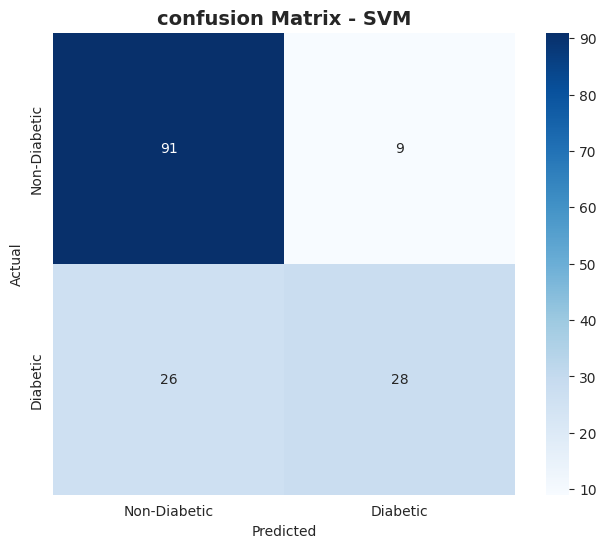

In [75]:
# Setting up the plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

# Adding labels and title
plt.title('confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

TASK 16: TRAINING RANDOM FOREST CLASSIFIER

In [76]:
# Initializing the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training data
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=2)

MAKE PREDICTIONS ON TRAINING DATA (RANDOM FOREST)

In [77]:
x_train_prediction_rf = rf_classifier.predict(x_train)

CALCULATE TRAINING ACCURACY (RANDOM FOREST)

In [78]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf,y_train)
training_data_accuracy_rf

1.0

CALCULATE TEST ACCURACY (RANDOM FOREST)

In [79]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf,y_test)

DISPLAY TEST ACCURACY (RANDOM FOREST)

In [80]:
test_data_accuracy_rf

0.7272727272727273

CALCULATE PRECISION (RANDOM FOREST)

In [81]:
precision_rf = precision_score(y_test,x_test_prediction_rf)


CALCULATE RECALL (RANDOM FOREST)

In [82]:
recall_rf = recall_score(y_test,x_test_prediction_rf)

CALCULATE F1-SCORE (RANDOM FOREST)

In [83]:
f1_rf = f1_score(y_test,x_test_prediction_rf)

DISPLAY PRECISION, RECALL AND F1-SCORE

In [84]:
print(precision_rf,recall_rf,f1_rf)

0.65 0.48148148148148145 0.5531914893617021


GENERATE CONFUSION MATRIX (RANDOM FOREST)

In [85]:
cm_rf = confusion_matrix(y_test,x_test_prediction_rf)
print(cm_rf)

[[86 14]
 [28 26]]


TASK 17: CONFUSION MATRIX VISUALIZATION (RANDOM FOREST)

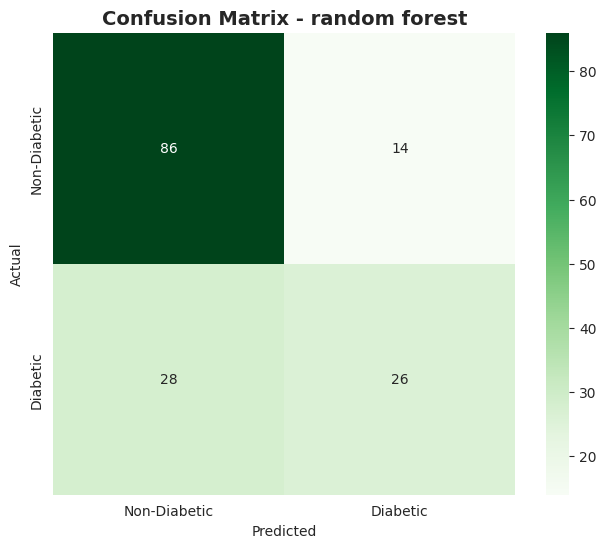

In [86]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])

plt.title('Confusion Matrix - random forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

TASK 18 COMPARE SVM AND RANDOM FOREST TEST ACCURACY

In [87]:
print('SVM', test_data_accuracy)
print('Random Forest', test_data_accuracy_rf)

SVM 0.7727272727272727
Random Forest 0.7272727272727273


TASK 19 SAVE TRAINED MODEL USING JOBLIB

In [88]:
joblib.dump(classifier,'diabetes_model.pkl')

['diabetes_model.pkl']

TASK 20 MAKE PREDICTION FOR NEW INPUT DATA

In [89]:
# Example input data (Pregnancies, Glucose, BloodPressure, etc.)
input_data = (5, 166, 72, 19, 175, 25.8, 0.587, 51)

# Changing input data to a numpy array
input_num_array = np.asarray(input_data)

# Reshape the array as we are predicting for one instance
reshape = input_num_array.reshape(1, -1)

# Standardize the input data using the scaler we created earlier
std_data = scaler.transform(reshape)

# Making the prediction
prediction = classifier.predict(std_data)

if (prediction[0] == 0):
    print('The person is not diabetic')
else:
    print('The person is diabetic')

The person is diabetic


DISPLAY PREDICTION RESULT

In [90]:
prediction

array([1])